In [1]:
import pandas as pd
import scipy.sparse as sp_sparse

df_ratings = pd.read_csv(r'D:\university\DataMining\Άσκηση 3\ratings_small.csv',low_memory=False)
df_links = pd.read_csv(r'D:\university\DataMining\Άσκηση 3\links_small.csv',low_memory=False)
df_movies = pd.read_csv(r'D:\university\DataMining\Άσκηση 3\movies_metadata.csv',low_memory=False)



rating_count = df_ratings.groupby('movieId').size()
rating_count = rating_count[rating_count >=10]

df_ratings_f = df_ratings[df_ratings['movieId'].isin(rating_count.index)].copy()

movies = df_ratings_f['movieId'].unique()
users = df_ratings_f['userId'].unique()


movie_i= {mid: i for i, mid in enumerate(movies)}
user_i = {uid: i for i, uid in enumerate(users)}

df_ratings_f['mid'] = df_ratings_f['movieId'].map(movie_i)
df_ratings_f['uid'] = df_ratings_f['userId'].map(user_i)

N = len(movies)
M = len(users)

R = sp_sparse.csr_matrix((df_ratings_f['rating'].values, (df_ratings_f['mid'].values, df_ratings_f['uid'].values)),
    shape=(N, M)
)


R.shape




(2245, 671)

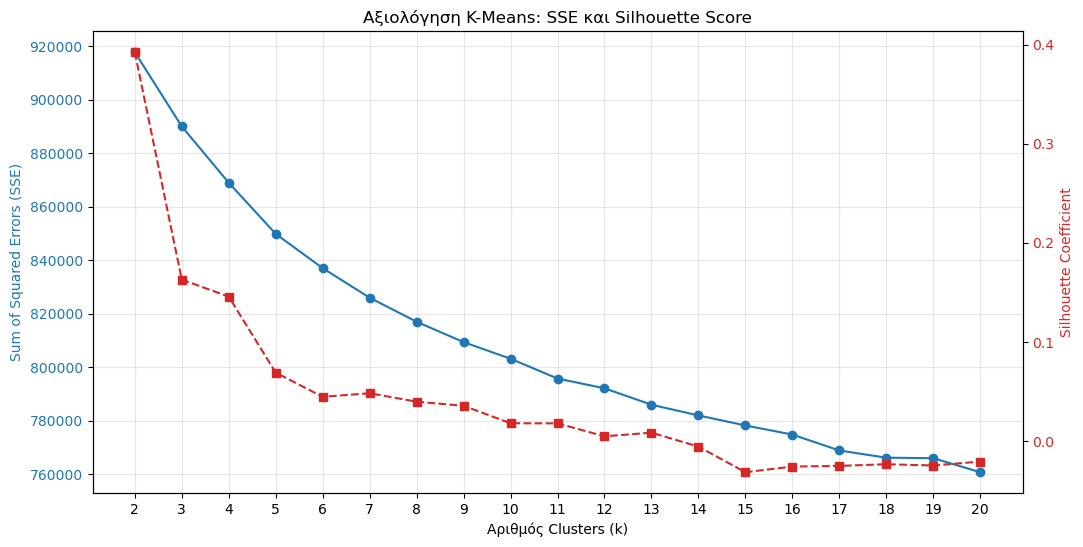

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

error=[]
sh_score =[]
k_range = range(2, 21)

for k in k_range:
    
    kmeans = KMeans(init='k-means++', n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(R)
    error.append(kmeans.inertia_)
    
    score= silhouette_score(R, labels)
    sh_score.append(score)
    
    
    

    
fig, ax1 = plt.subplots(figsize=(12, 6))


color = 'tab:blue' 
ax1.set_xlabel('Αριθμός Clusters (k)')
ax1.set_ylabel('Sum of Squared Errors (SSE)', color=color)

ax1.plot(k_range, error, color=color, marker='o', label='SSE') 
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)


ax2 = ax1.twinx()  
color = 'tab:red'   
ax2.set_ylabel('Silhouette Coefficient', color=color)
ax2.plot(k_range, sh_score, color=color, marker='s', linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Αξιολόγηση K-Means: SSE και Silhouette Score')
plt.xticks(k_range)

plt.show()

Βλέπουμε ξεκάθαρα ότι στο διάστημα που μας ζητείται, η επιλογή που θα κάνουμε είναι το κ=2, όπου παρουσιάζεται το μεγαλύτερο sihouette score.Βλέπουμε επίσης την τεράστια πτώση της καμπύλης απο κ=2 σε κ=3, οπότε μπορούμε να πούμε ότι εκεί έχουμε το elbow point.

In [3]:
best_k =2
kmeans_final = KMeans(init='k-means++', n_clusters=best_k, n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(R)

df_clusters = pd.DataFrame({
    'movieId': movies,  
    'cluster': cluster_labels 
})


print(df_clusters['cluster'].value_counts()) 

cluster
1    1998
0     247
Name: count, dtype: int64


In [4]:
import ast
df_movies = df_movies[['id', 'genres', 'title']].copy()
df_movies['id'] = pd.to_numeric(df_movies['id'], errors='coerce')
df_movies = df_movies.dropna(subset=['id'])
df_movies['id'] = df_movies['id'].astype(int)


df_links_clusters = df_clusters.merge(df_links, on='movieId')

df_final = df_links_clusters.merge(df_movies, left_on='tmdbId', right_on='id')

df_final['genres'] = df_final['genres'].apply(lambda x: [x['name'] for x in ast.literal_eval(x)] )


genres_all = df_final['genres'].explode()
movies_all = len(df_final)

frequency = genres_all.value_counts()/movies_all



n_clusters = df_final['cluster'].nunique()
print(f"K-Means : Βρέθηκαν {n_clusters} clusters.")

for i in range(n_clusters):
    
    print(f"cluster {i} :")
    df_cluster = df_final[df_final['cluster'] == i]
    
    if len(df_cluster) > 0:
        
        genres_cluster = df_cluster['genres'].explode()

        cluster_frequency = genres_cluster.value_counts() / len(df_cluster)
    
        lift = cluster_frequency / frequency
    
        top3 = lift.sort_values(ascending=False).head(3)
    
        print(top3)
        print("\n")

K-Means : Βρέθηκαν 2 clusters.
cluster 0 :
genres
Fantasy    1.404354
Crime      1.272690
Family     1.265706
Name: count, dtype: float64


cluster 1 :
genres
Documentary    1.123810
Horror         1.056827
Western        1.041580
Name: count, dtype: float64




Βλέπουμε ότι με τον αλγόριθμο K-means τα 2 clusters χωρίζονται αρκετά ανισσομερώς.
Τόσο η κατανομή αριθμητικά , όσο και οι κατηγορίες των ταινίων με το μεγαλύτερο lift, μας δείχνουν ίσως ότι στο ένα cluster έχουμε τα πιο mainstream είδη και στο άλλο πιο "ειδικές" κατηγορίες, όπως πχ τα ντοκιμαντερ.Eκεί ίσως οι κατηγορίες αυτές βγήκαν πάνω καθώς η συχνότητα τους στο σύνολο είναι σχεδόν ίδια με εκείνη στο cluster, καθώς μιλάμε για το cluster με το μεγαλύτερο μέρος των ταινιών(Βλέπουμε και ότι τα Lifts είναι κοντά στο 1, πράγμα που σημαίνει ότι μάλλον αφαιρέσαμε τα πολύ δημοφιλή είδη και μας μείνανε τα υπόλοιπα).

# Agglomerative clustering


In [5]:
from sklearn.cluster import AgglomerativeClustering
agglo = AgglomerativeClustering(linkage = 'ward', n_clusters = 2)

agglo_labels = agglo.fit_predict(R.toarray())

df_clusters_agg = pd.DataFrame({
    'movieId': movies,  
    'cluster': agglo_labels 
})

print(df_clusters_agg['cluster'].value_counts())

cluster
0    2021
1     224
Name: count, dtype: int64


In [6]:

df_links_agg = df_clusters_agg.merge(df_links, on='movieId')

df_final_agg = df_links_agg.merge(df_movies, left_on='tmdbId', right_on='id')

df_final_agg['genres'] = df_final_agg['genres'].apply(lambda x: [x['name'] for x in ast.literal_eval(x)] )


genres_all2 = df_final_agg['genres'].explode()
movies_all2 = len(df_final_agg)

frequency_agg = genres_all2.value_counts()/movies_all2


n_clusters2 = df_final_agg['cluster'].nunique()
print(f"Agglomerative clustering: Βρέθηκαν {n_clusters2} clusters.")

for i in range(n_clusters2):
    
    print(f"cluster {i} :")
    df_cluster_agg = df_final_agg[df_final_agg['cluster'] == i]
    
    if len(df_cluster_agg) > 0:
        
        genres_cluster = df_cluster_agg['genres'].explode()
        
        cluster_frequency2 = genres_cluster.value_counts() / len(df_cluster_agg)
    
        lift_agg= cluster_frequency2 / frequency_agg
    
        top3_agg = lift_agg.sort_values(ascending=False).head(3)
    
        print(top3_agg)
        print("\n")

Agglomerative clustering: Βρέθηκαν 2 clusters.
cluster 0 :
genres
Documentary    1.111001
Western        1.083903
Horror         1.059498
Name: count, dtype: float64


cluster 1 :
genres
Fantasy    1.435243
Action     1.421933
Crime      1.270975
Name: count, dtype: float64




Κάτι παρόμοιο με τον K-means παρατηρούμε και για το Agglomerative clustering, τόσο στον αριθμό του κάθε cluster όσο και στα lift των κορυφαίων κατηγοριών. Μόνη διαφοροποίηση η άνοδος στο lift των Action ταινιών, κάτι που απλά μπορεί να μας δείξει ότι υπάρχει μια μικρή αλλαγή στην επιλογή των ταινιών που μπήκαν στο μικρό σε μέγεθος cluster (χρησιμοποιηθηκε linkage = 'ward' αντί για 'complete' που αναφέρεται στο Φροντηστήριο 7 , λόγω του ότι το ward ελαχιστοποιεί τη διακύμανση, οπότε ίσως γι αυτό εκτοξεύτηκε το action είδος, αφού οι mainstream είναι πάρα πολύ συχνά ταινίες δράσης).

# PCA

In [7]:
from sklearn.decomposition import PCA


pca = PCA(n_components=50)
R_pca = pca.fit_transform(R.toarray())




kmeans_pca = KMeans(init='k-means++', n_clusters=2, n_init=10, random_state=42)
pca_labels= kmeans_pca.fit_predict(R_pca)


df_clusters_pca = pd.DataFrame({
    'movieId': movies,  
    'cluster': pca_labels 
})


print(df_clusters_pca['cluster'].value_counts())

cluster
1    2002
0     243
Name: count, dtype: int64


In [8]:

df_links_pca= df_clusters_pca.merge(df_links, on='movieId')

df_final_pca = df_links_pca.merge(df_movies, left_on='tmdbId', right_on='id')

df_final_pca['genres'] = df_final_pca['genres'].apply(lambda x: [x['name'] for x in ast.literal_eval(x)] )



genres_all3 = df_final_pca['genres'].explode()
movies_all3 = len(df_final_pca)

frequency_pca = genres_all3.value_counts()/movies_all3


n_clusters3 = df_final_pca['cluster'].nunique()
print(f"PCA: Βρέθηκαν {n_clusters2} clusters.")

for i in range(n_clusters3):
    
    print(f"cluster {i} :")
    df_cluster_pca = df_final_pca[df_final_pca['cluster'] == i]
    
    if len(df_cluster_pca) > 0:
        
        genres_cluster = df_cluster_pca['genres'].explode()
        
        cluster_frequency3 = genres_cluster.value_counts() / len(df_cluster_pca)
    
        lift_pca= cluster_frequency3 / frequency_pca
    
        top3_pca = lift_pca.sort_values(ascending=False).head(3)
    
        print(top3_pca)
        print("\n")

PCA: Βρέθηκαν 2 clusters.
cluster 0 :
genres
Fantasy    1.427471
Family     1.286541
Crime      1.269232
Name: count, dtype: float64


cluster 1 :
genres
Documentary    1.121561
Horror         1.069568
Western        1.039495
Name: count, dtype: float64




Και για το PCA δεν παρατηρούμε κάποια μεγάλη διαφορά. Εδώ βλέπουμε ότι ο αλγόριθμος μοιάζει πιο πολύ με τον k-means, αν παρατηρήσουμε την παρουσία των Family ταινιών και όχι των Action. 

Γενικά, η μεγάλη ομοιότητα και στους τρεις διαφορετικούς τρόπους clustering μας δείχνει ότι για τον συγκεκριμένο διαχωρισμό (2 clusters), η λογική με την οποία "σπάμε" τα δεδομένα παραμένει η ίδια. 

# TF-IDF

In [9]:
movies_new = pd.read_csv(r'D:\university\DataMining\Άσκηση 3\movies_metadata.csv',low_memory=False)

movies_new = movies_new[['id', 'genres', 'title','overview']].copy()
movies_new['id'] = pd.to_numeric(df_movies['id'], errors='coerce')
movies_new = movies_new.dropna(subset=['id'])
movies_new['id'] = movies_new['id'].astype(int)


movies_new['genres'] = movies_new['genres'].apply(lambda x: [i['name'] for i in ast.literal_eval(x)] if isinstance(x, str) else [])


genres_to_keep = {'War','Music','Animation'}
movies_new_final = movies_new[movies_new['genres'].apply(lambda x: len(set(x) & genres_to_keep) == 1)].copy()
movies_new_final = movies_new_final.dropna(subset=['overview'])
movies_new_final['chosen_genre'] = movies_new_final['genres'].apply(lambda x: list(set(x) & genres_to_keep)[0])
movies_new_final



,id,genres,title,overview,chosen_genre
0,862,"[Animation, Comedy, Family]",Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation
12,21032,"[Family, Animation, Adventure]",Balto,An outcast half-wolf risks his life to prevent...,Animation
40,31174,"[Drama, War]",Richard III,Shakespeare's Play transplanted into a 1930s s...,War
47,10530,"[Adventure, Animation, Drama, Family]",Pocahontas,History comes gloriously to life in Disney's e...,Animation
61,2054,"[Music, Drama, Family]",Mr. Holland's Opus,"In 1965, passionate musician Glenn Holland tak...",Music
...,...,...,...,...,...
45386,175457,[Animation],Opus II,An abstract animation from Walter Ruttmann.,Animation
45388,184402,[Animation],Opus IV,An abstract animation by Walter Ruttmann.,Animation
45433,5589,"[Music, Comedy, Family]",Šíleně smutná princezna,No overview found.,Music
45437,455661,"[Family, Animation, Romance, Comedy]",In a Heartbeat,A closeted boy runs the risk of being outed by...,Animation


In [10]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
import sklearn.model_selection as model_selection
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix



X = movies_new_final['overview']
y= movies_new_final['chosen_genre']


classifiers = [
    LogisticRegression(solver='lbfgs',max_iter=1000),
    DecisionTreeClassifier(),
    KNeighborsClassifier(),
    SVC(),
    MLPClassifier(max_iter=1000)
]


for c in classifiers:
    
    clf_name = c.__class__.__name__
    print(f"Running {clf_name}...")
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
        ('classifier', c)])
    
    
    scores =  model_selection.cross_validate(pipeline,X,y,scoring=['accuracy', 'precision_macro', 'recall_macro'],cv=5)
    
    
    
    prediction = cross_val_predict(pipeline, X, y, cv=5)
    
    matrix = confusion_matrix(y, prediction)
    print("Confusion Matrix:")
    print(matrix)
    
    
    print(f"Accuracy: {np.mean(scores['test_accuracy']):.4f}")
    print(f"Precision: {np.mean(scores['test_precision_macro']):.4f}")
    print(f"Recall:    {np.mean(scores['test_recall_macro']):.4f}")
    print("\n")

Running LogisticRegression...
Confusion Matrix:
[[1688  106   43]
 [ 235 1232   43]
 [ 124   64 1095]]
Accuracy: 0.8672
Precision: 0.8769
Recall:    0.8628


Running DecisionTreeClassifier...
Confusion Matrix:
[[1227  375  235]
 [ 289 1109  112]
 [ 155  113 1015]]
Accuracy: 0.7220
Precision: 0.7234
Recall:    0.7287


Running KNeighborsClassifier...
Confusion Matrix:
[[1420  249  168]
 [ 327 1046  137]
 [ 144  150  989]]
Accuracy: 0.7462
Precision: 0.7554
Recall:    0.7455


Running SVC...
Confusion Matrix:
[[1700   98   39]
 [ 251 1222   37]
 [ 153   59 1071]]
Accuracy: 0.8624
Precision: 0.8760
Recall:    0.8565


Running MLPClassifier...
Confusion Matrix:
[[1570  186   81]
 [ 211 1224   75]
 [  82   79 1122]]
Accuracy: 0.8462
Precision: 0.8482
Recall:    0.8468




# Word2Vec

In [11]:
import gensim.downloader as api
from gensim import utils
print("Φόρτωση μοντέλου...")



path = api.load("word2vec-google-news-300")
print("Το μοντέλο φορτώθηκε!")
print(f"Διάσταση διανυσμάτων: {path.vector_size}")



def vector(text,model):
    
    words = utils.simple_preprocess(text)

    word_vectors = [model[w] for w in words if w in model]

    words_mean = np.mean(word_vectors, axis=0)

    return words_mean


X_new = [vector(t, path) for t in X]
X_w2v = np.vstack(X_new)
X_w2v.shape    




for c in classifiers:
    
    clf_name = c.__class__.__name__
    print(f"Running {clf_name}...")
    
    
    scores =  model_selection.cross_validate(c,X_w2v,y,scoring=['accuracy', 'precision_macro', 'recall_macro'],cv=5)
    
    prediction = cross_val_predict(c, X_w2v, y, cv=5)
    
    
    matrix = confusion_matrix(y, prediction)
    print("Confusion Matrix:")
    print(matrix)
    
    print(f"Accuracy: {np.mean(scores['test_accuracy']):.4f}")
    print(f"Precision: {np.mean(scores['test_precision_macro']):.4f}")
    print(f"Recall:    {np.mean(scores['test_recall_macro']):.4f}")
    print("\n")

Φόρτωση μοντέλου...
Το μοντέλο φορτώθηκε!
Διάσταση διανυσμάτων: 300
Running LogisticRegression...
Confusion Matrix:
[[1631  122   84]
 [ 175 1291   44]
 [  90   56 1137]]
Accuracy: 0.8767
Precision: 0.8796
Recall:    0.8764


Running DecisionTreeClassifier...
Confusion Matrix:
[[1203  364  270]
 [ 359  967  184]
 [ 232  188  863]]
Accuracy: 0.6529
Precision: 0.6518
Recall:    0.6543


Running KNeighborsClassifier...
Confusion Matrix:
[[1512  204  121]
 [ 194 1236   80]
 [  94   86 1103]]
Accuracy: 0.8317
Precision: 0.8324
Recall:    0.8338


Running SVC...
Confusion Matrix:
[[1642  124   71]
 [ 165 1301   44]
 [  82   57 1144]]
Accuracy: 0.8827
Precision: 0.8857
Recall:    0.8824


Running MLPClassifier...
Confusion Matrix:
[[1567  172   98]
 [ 163 1279   68]
 [  91   72 1120]]
Accuracy: 0.8594
Precision: 0.8600
Recall:    0.8615




# Results

# TF -IDF

|Classifier| Accuracy | Precision| Recall|
|:-- | :-- | :-- | :-- |
|LogisticRegression| 0.8672| 0.8769 |0.8628|
|DecisionTreeClassifier | 0.7212 |0.7240| 0.7289|
|KNeighborsClassifier | 0.7462 |0.7554| 0.7455|
|SVC | 0.8624 |0.8760 | 0.8565|
|MLPClassifier |0.8464 |0.8486| 0.8474|





# Word2Vec

|Classifier| Accuracy | Precision| Recall|
|:-- | :-- | :-- | :-- |
|LogisticRegression|0.8767 |0.8796 | 0.8764|
|DecisionTreeClassifier |0.6531 | 0.6534| 0.6539|
|KNeighborsClassifier | 0.8317| 0.8324| 0.8338|
|SVC |  0.8827| 0.8857| 0.8824|
|MLPClassifier |0.8579| 0.8597| 0.8584|


Βλέπουμε ότι για το TF-IDF η καλύτερη επιλογή με βάση το accuracy είναι ο Logistic Regression classifier και , έπειτα, οι SVC και MLP. Το γεγονός ότι τα οι τρεις αυτες μεθοδοι μας δινουν καλύτερο precision επαληθεύεται από τα αντίστοιχα confusion matrix , όπου βλέπουμε ότι οι προβλέψεις τους είναι πιο συχνά σωστές (αμα συγκρίνουμε το σύνολο στα υπόλοιπα κελιά της ίδιας στήλης είναι λιγότερα από τις άλλες δύο μεθόδους), ενώ βλέπουμε ότι οι ίδιες τρεις μας δίνουν και καλύτερο recall , σε αντίθεση με τα Decision Tree και KNeighbors, όπου το recall τους είναι χαμηλότερο (αν δούμε τους πίνακες χάνουν περισσότερα στην ίδια γραμμή σε σχέση με τους άλλους, που σημαίνει ότι περισσότερες ταινίες που ανήκουν στο εκάστοτε είδος δεν προβλέπονται σωστά)  

Για το Word2Vec, παρατηρούμε ότι για όλες τις μεθόδους, εκτός από το Decision Tree, έχουμε παρόμοια σχεδόν αποτελέσματα για όλες τις μετρικές, με το SVC να αποδικνύεται έστω και για λίγο η καλύτερη επιλογή. Πολύ κακές τιμές παρουσιάζει ο Decision Tree, δείχνοντας ότι είναι με διαφορά ο πιο αναξιόπιστος αλγόριθμος για τον συγκεκριμένο τρόπο εξαγωγης χαρακτηριστικών. 

# Implementation using a different text 

In [12]:
my_text1 = ["A lonely soldier plays the piano while waiting for the battle to begin"] #war
my_text2 = ["A magical princess sings a song to save her frozen kingdom"] ##animation
my_text3 = ["An army of robots destroys the city with advanced laser weapons"] # war/animation

for c in classifiers:
    
    clf_name = c.__class__.__name__
    print(f"Running {clf_name}...")
    text_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
        ('classifier', c)])
    
    
    text_pipeline.fit(X,y)
    
    prediction1 = text_pipeline.predict(my_text1)
    prediction2 = text_pipeline.predict(my_text2)
    prediction3 = text_pipeline.predict(my_text3)
    
    print(f"prediction for text 1 is: {prediction1}")
    print(f"prediction for text 2 is: {prediction2}")
    print(f"prediction for text 3 is: {prediction3}")
    print("\n")

Running LogisticRegression...
prediction for text 1 is: ['War']
prediction for text 2 is: ['Animation']
prediction for text 3 is: ['Animation']


Running DecisionTreeClassifier...
prediction for text 1 is: ['War']
prediction for text 2 is: ['Animation']
prediction for text 3 is: ['War']


Running KNeighborsClassifier...
prediction for text 1 is: ['Animation']
prediction for text 2 is: ['Animation']
prediction for text 3 is: ['Animation']


Running SVC...
prediction for text 1 is: ['War']
prediction for text 2 is: ['Animation']
prediction for text 3 is: ['Animation']


Running MLPClassifier...
prediction for text 1 is: ['War']
prediction for text 2 is: ['Animation']
prediction for text 3 is: ['Animation']




In [13]:

text_vector1 = vector(my_text1[0],path)
text_vector2 = vector(my_text2[0],path)
text_vector3 = vector(my_text3[0],path)

text_vector1 = text_vector1.reshape(1, -1)
text_vector2 = text_vector2.reshape(1, -1)
text_vector3 = text_vector3.reshape(1, -1)


for c in classifiers:
    
    clf_name = c.__class__.__name__
    print(f"Running {clf_name}...")
    
        
    
    
    c.fit(X_w2v, y)
    
    prediction1 = c.predict(text_vector1)
    prediction2 = c.predict(text_vector2)
    prediction3 = c.predict(text_vector3)
    
    print(f"prediction for text 1 is: {prediction1}")
    print(f"prediction for text 2 is: {prediction2}")
    print(f"prediction for text 3 is: {prediction3}")
    print("\n")

Running LogisticRegression...
prediction for text 1 is: ['War']
prediction for text 2 is: ['Animation']
prediction for text 3 is: ['Animation']


Running DecisionTreeClassifier...
prediction for text 1 is: ['Music']
prediction for text 2 is: ['War']
prediction for text 3 is: ['Animation']


Running KNeighborsClassifier...
prediction for text 1 is: ['War']
prediction for text 2 is: ['Animation']
prediction for text 3 is: ['Animation']


Running SVC...
prediction for text 1 is: ['Animation']
prediction for text 2 is: ['Animation']
prediction for text 3 is: ['Animation']


Running MLPClassifier...
prediction for text 1 is: ['Music']
prediction for text 2 is: ['Animation']
prediction for text 3 is: ['Animation']




Για να παρατηρήσουμε τα δύο μοντέλα , εισάγουμε τρεις διαφορετικές περιγραφές.

Για τη πρώτη περιγραφή, βλέπουμε ότι για το TF-IDF όλες οι μέθοδοι εκτός από τον KNeighbors προέβλεψαν σωστά. Στο Word2Vec βλέπουμε ότι υπήρξε σύγχηση, μάλλον οφειλούμενη στο γεγονός ότι υπολογίζει μέσους όρους , οπότε λέξεις όπως piano , lonely να τράβηξαν τα αποτελέσματα προς αλλές κατευθύνσεις.

Στη δεύτερη, έχουμε μια πρόταση που 'δείχνει' ξεκάθαρα την κατηγορία Animation και , πράγματι, και στους δύο τρόπους οι προβλέψεις είναι σωστές παντού. Εξαίρεση το Decision Tree , λογικά επειδή η λέξη kingdom τράβηξε το αποτέλεσμα στο μονοπάτι του δέντρου που οδηγεί στο war.

Στην τρίτη περιγραφή, έχουμε μια περιγραφή όπου σαφώς μας υποδικνύει προς τη κατηγορία war , όμως μας δίνει και μια αίσθηση ότι μπορεί να έχουμε αρκετά στοιχεία animation. Πράγματι, βλέπουμε αρχικά για το TF-IDF σχεδόν όλες οι μέθοδοι προέβλεψαν animation και έπειτα στο Word2Vec για όλες τις ταινίες πήραμε αποτελέσματα προς αυτή την κατηγορία. Δε μπορούμε σε καμία περίπτωση να πούμε ότι προέβλεψαν λάθος, αλλά τα αποτελέσματα δείχνουν ότι οι λέξεις robots, laser υπερίσχυσαν των army, weapons.